1. Adım: Veri Hazırlığı ve Orijinal Resimler
Burada sadece giriş verimizi (tertemiz halini) görüyoruz.

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.09MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 133kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.10MB/s]


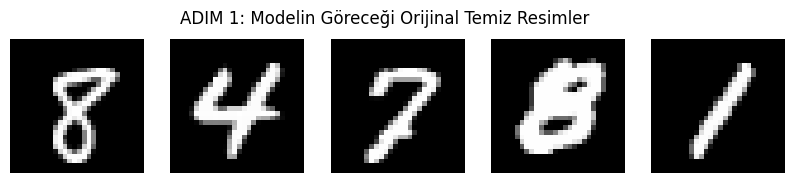

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# GPU/CPU ayarı
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Veriyi indir
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=10, shuffle=True)

# 1. GÖRSELLEŞTİRME: Orijinal Resimler
dataiter = iter(train_loader)
images, _ = next(dataiter)

plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(images[i].numpy().squeeze(), cmap='gray')
    plt.axis('off')
plt.suptitle("ADIM 1: Modelin Göreceği Orijinal Temiz Resimler")
plt.show()

2. Adım: Model ve Bottleneck (Sıkıştırılmış Hal)
Modeli eğittikten sonra (veya eğitmeden önce yapısını görmek için), resmin 32 sayılık "kod" halini (Latent Space) görselleştiriyoruz.

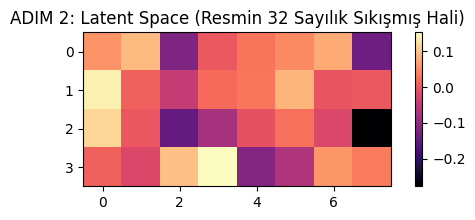

In [2]:
# Model Tanımı
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(nn.Linear(28*28, 128), nn.ReLU(), nn.Linear(128, 32))
        self.decoder = nn.Sequential(nn.Linear(32, 128), nn.ReLU(), nn.Linear(128, 28*28), nn.Sigmoid())

    def forward(self, x):
        x = x.view(-1, 28*28)
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded.view(-1, 1, 28, 28), encoded

model = Autoencoder().to(device)

# 2. GÖRSELLEŞTİRME: Latent Space (Sıkıştırılmış Veri)
# Bir resmi encode edelim
img = images[0].to(device).view(-1, 28*28)
with torch.no_grad():
    latent_space = model.encoder(img)

plt.figure(figsize=(6, 2))
plt.imshow(latent_space.cpu().numpy().reshape(4, 8), cmap='magma')
plt.colorbar()
plt.title("ADIM 2: Latent Space (Resmin 32 Sayılık Sıkışmış Hali)")
plt.show()

3. Adım: Gürültü Ekleme (Kirli Veri)
Modelin temizlemesi gereken "zorlu" şartları oluşturuyoruz.

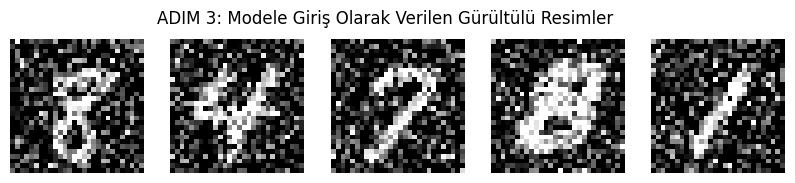

In [3]:
def add_noise(img):
    return torch.clamp(img + 0.4 * torch.randn_like(img), 0., 1.)

noisy_images = add_noise(images.to(device))

# 3. GÖRSELLEŞTİRME: Kirli Veri
plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(noisy_images[i].cpu().numpy().squeeze(), cmap='gray')
    plt.axis('off')
plt.suptitle("ADIM 3: Modele Giriş Olarak Verilen Gürültülü Resimler")
plt.show()

4. Adım: Final Karşılaştırması (Orijinal - Kirli - Çıktı)
İşte sunumda "İşlem tamam" diyeceğin yer burası. Her şeyi yan yana koyuyoruz.

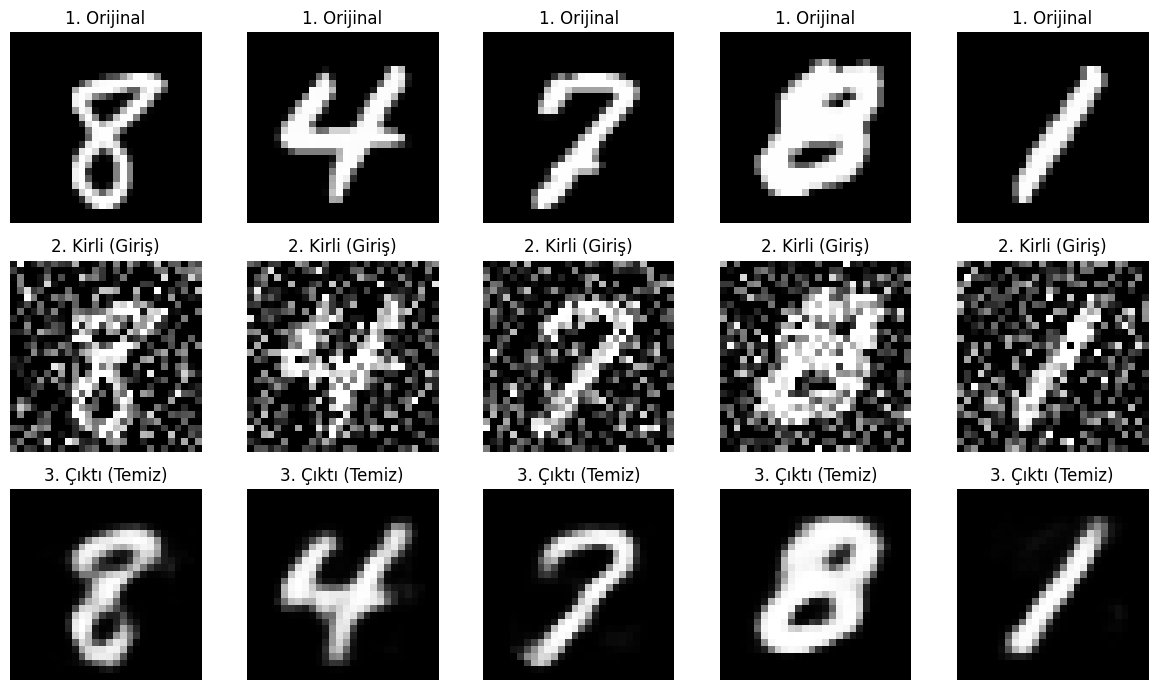

In [4]:
# Modeli kısa bir eğitimden geçirelim (Sunumda bu kısmı hızlıca çalıştırabilirsin)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

for epoch in range(3): # Hızlı sonuç için 3 epoch
    for data in train_loader:
        img, _ = data
        img = img.to(device)
        output, _ = model(add_noise(img))
        loss = criterion(output, img)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

# 4. GÖRSELLEŞTİRME: Final Karşılaştırma
model.eval()
with torch.no_grad():
    reconstructed, _ = model(noisy_images)

fig, axes = plt.subplots(3, 5, figsize=(12, 7))
for i in range(5):
    # Orijinal
    axes[0, i].imshow(images[i].numpy().squeeze(), cmap='gray')
    axes[0, i].set_title("1. Orijinal")
    axes[0, i].axis('off')
    # Kirli
    axes[1, i].imshow(noisy_images[i].cpu().numpy().squeeze(), cmap='gray')
    axes[1, i].set_title("2. Kirli (Giriş)")
    axes[1, i].axis('off')
    # Çıktı (Decoded)
    axes[2, i].imshow(reconstructed[i].cpu().numpy().squeeze(), cmap='gray')
    axes[2, i].set_title("3. Çıktı (Temiz)")
    axes[2, i].axis('off')

plt.tight_layout()
plt.show()